# Analysing the results found by each simulation

In [ ]:
# GROUP : 23
# DATE : 28.03.2025
# MEMBERS :
# - ZUO Yuxian
# - NADALIN	Marius
# - EL BARHICHI	Mohammed

### Imports & setup

In [1]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
files = glob.glob('benchmarks/model_*.csv')   
dfs = []
for fp in files:
    df = pd.read_csv(fp)
    fname = os.path.basename(fp).replace('.csv','').split('_')
    model_num = fname[1]
    scenario = '_'.join(fname[2:])
    df['model'] = f'model_{model_num}'
    df['scenario'] = scenario
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
all_df['steps_if_term'] = all_df['nb_steps'].where(all_df['terminated'], np.nan)

model_order    = ['model_1','model_2','model_3']
scenario_order = [
    'no_comm_no_drop',
    'no_comm_drop',
    'comm_1_only',
    'comm_1_and_comm_2'
]

all_df['model']    = pd.Categorical(all_df['model'],    categories=model_order,    ordered=True)
all_df['scenario'] = pd.Categorical(all_df['scenario'], categories=scenario_order, ordered=True)
all_df = all_df.sort_values(['model','scenario']).reset_index(drop=True)



In [4]:
def show_results(df: pd.DataFrame, title: str = None) -> None:
    if title:
        print(f"\n{title}\n" + "-"*len(title))
    df_term = df[df['terminated']]
    print("Average Steps (terminated runs):", f"{df_term['nb_steps'].mean():.2f}")
    print("Max Steps:",                   f"{df_term['nb_steps'].max():.2f}")
    print("Min Steps:",                   f"{df_term['nb_steps'].min():.2f}")
    print("Termination Rate (%):",        f"{df['terminated'].mean() * 100:.2f}")

    if 'nb_sent_msgs_comm_1' in df.columns:
        print("Avg comm_1 msgs:",    f"{df['nb_sent_msgs_comm_1'].mean():.2f}")
    if 'nb_sent_msgs_comm_2' in df.columns:
        print("Avg comm_2 msgs:",    f"{df['nb_sent_msgs_comm_2'].mean():.2f}")
        
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    df_term['nb_steps'].plot.box(title='Score Distribution', ax=axes[0])
    df_term['nb_steps'].plot.hist(bins=30, title='Score Histogram', ax=axes[1])
    plt.tight_layout()
    plt.show()

### Visualizing the ditribution for each scenario in each model

Results for Model 1 :

Model 1 — No Comm No Drop
-------------------------
Average Steps (terminated runs): 85.04
Max Steps: 311.00
Min Steps: 32.00
Termination Rate (%): 61.20
Avg comm_1 msgs: 0.00
Avg comm_2 msgs: 0.00


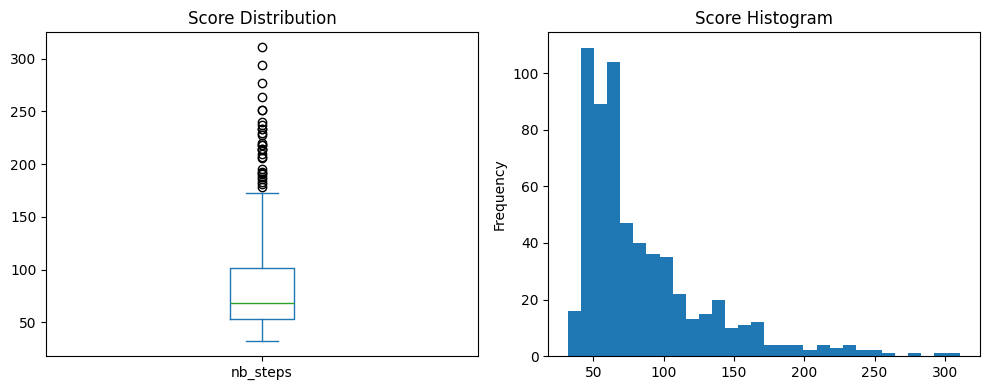


Model 1 — No Comm Drop
----------------------
Average Steps (terminated runs): 115.26
Max Steps: 479.00
Min Steps: 33.00
Termination Rate (%): 100.00
Avg comm_1 msgs: 0.00
Avg comm_2 msgs: 0.00


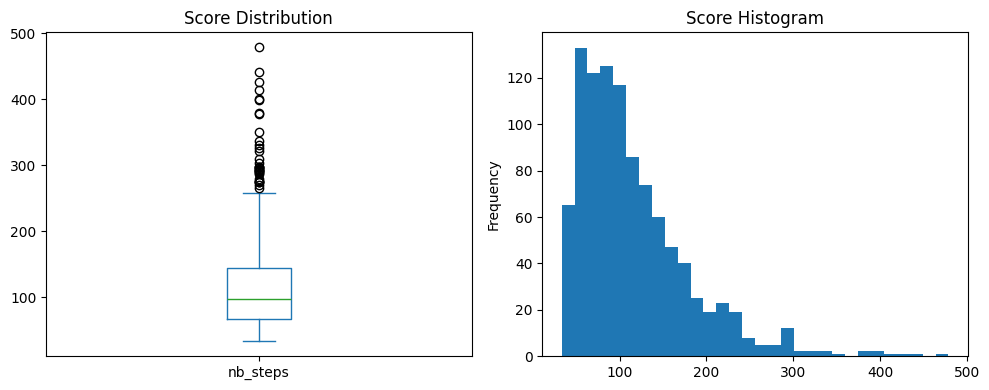


Model 1 — Comm 1 Only
---------------------
Average Steps (terminated runs): 67.16
Max Steps: 132.00
Min Steps: 35.00
Termination Rate (%): 100.00
Avg comm_1 msgs: 21.89
Avg comm_2 msgs: 0.00


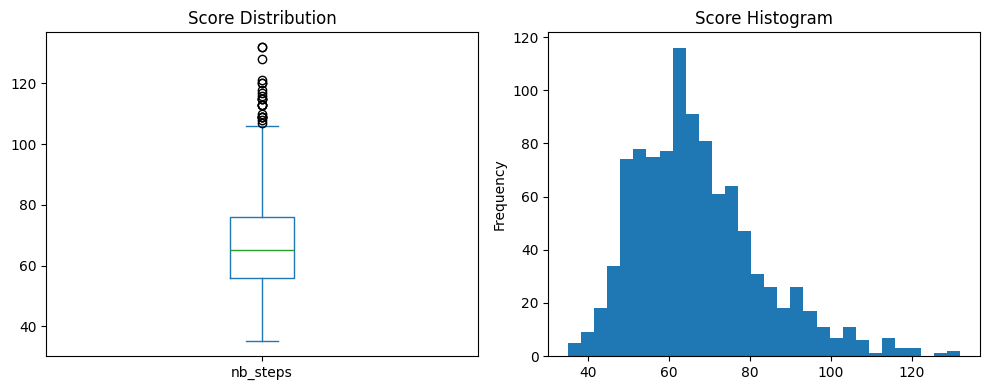


Model 1 — Comm 1 And Comm 2
---------------------------
Average Steps (terminated runs): 53.75
Max Steps: 84.00
Min Steps: 34.00
Termination Rate (%): 100.00
Avg comm_1 msgs: 21.39
Avg comm_2 msgs: 12.00


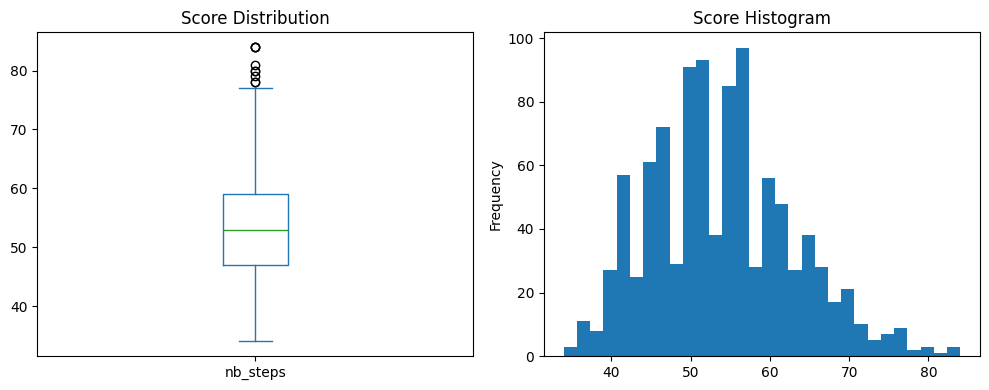



Results for Model 2 :

Model 2 — No Comm No Drop
-------------------------
Average Steps (terminated runs): 101.37
Max Steps: 226.00
Min Steps: 52.00
Termination Rate (%): 100.00
Avg comm_1 msgs: 0.00
Avg comm_2 msgs: 0.00


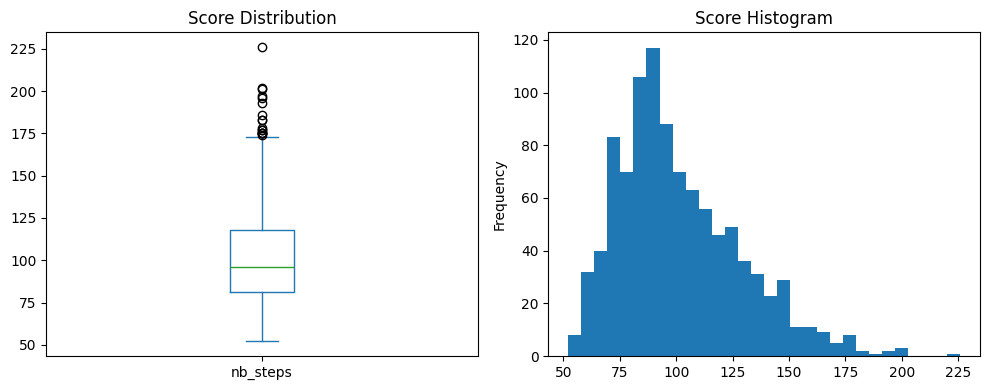


Model 2 — No Comm Drop
----------------------
Average Steps (terminated runs): 100.88
Max Steps: 225.00
Min Steps: 54.00
Termination Rate (%): 100.00
Avg comm_1 msgs: 0.00
Avg comm_2 msgs: 0.00


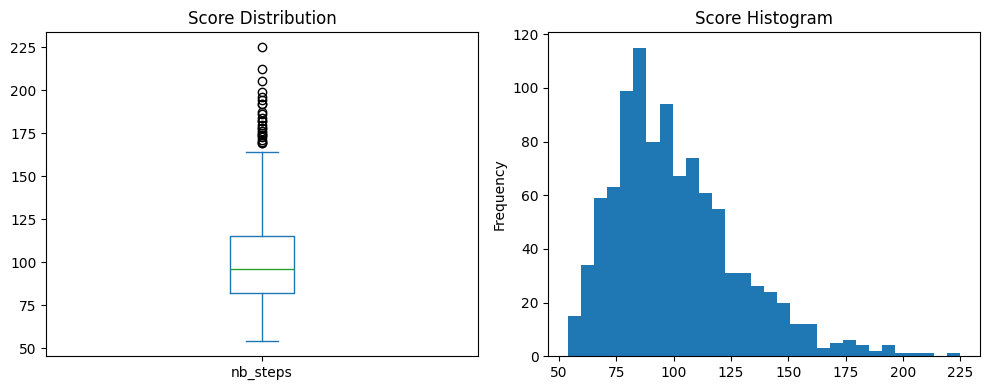


Model 2 — Comm 1 Only
---------------------
Average Steps (terminated runs): 99.41
Max Steps: 205.00
Min Steps: 50.00
Termination Rate (%): 100.00
Avg comm_1 msgs: 0.00
Avg comm_2 msgs: 0.00


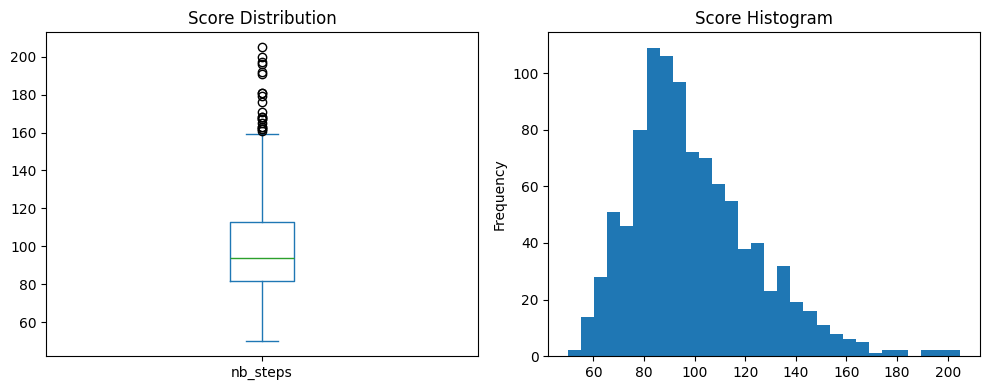


Model 2 — Comm 1 And Comm 2
---------------------------
Average Steps (terminated runs): 69.89
Max Steps: 132.00
Min Steps: 50.00
Termination Rate (%): 100.00
Avg comm_1 msgs: 0.00
Avg comm_2 msgs: 6.00


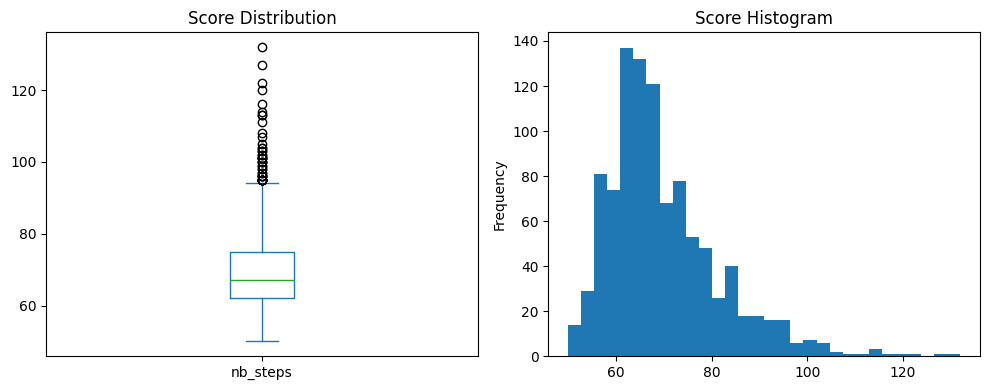



Results for Model 3 :

Model 3 — No Comm No Drop
-------------------------
Average Steps (terminated runs): 351.23
Max Steps: 984.00
Min Steps: 89.00
Termination Rate (%): 16.30
Avg comm_1 msgs: 0.00
Avg comm_2 msgs: 0.00


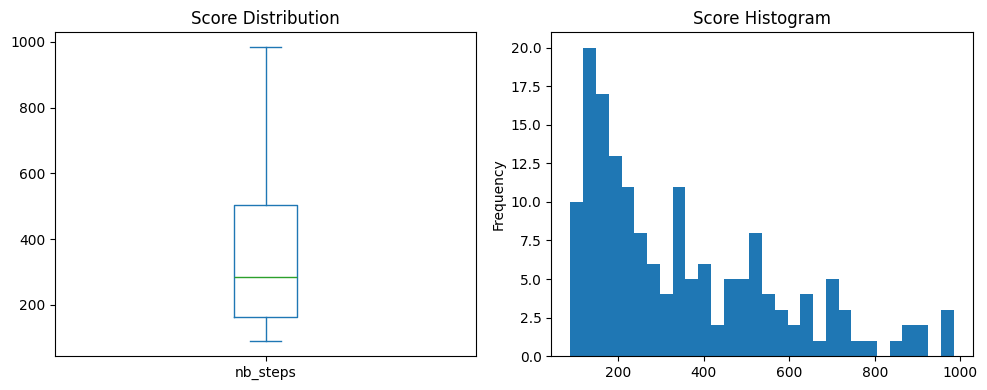


Model 3 — No Comm Drop
----------------------
Average Steps (terminated runs): 499.93
Max Steps: 999.00
Min Steps: 78.00
Termination Rate (%): 80.80
Avg comm_1 msgs: 0.00
Avg comm_2 msgs: 0.00


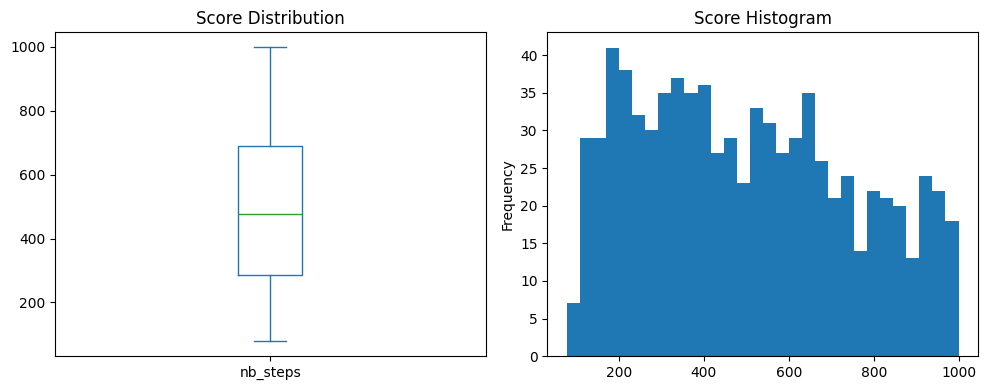


Model 3 — Comm 1 Only
---------------------
Average Steps (terminated runs): 164.70
Max Steps: 363.00
Min Steps: 86.00
Termination Rate (%): 100.00
Avg comm_1 msgs: 131.49
Avg comm_2 msgs: 0.00


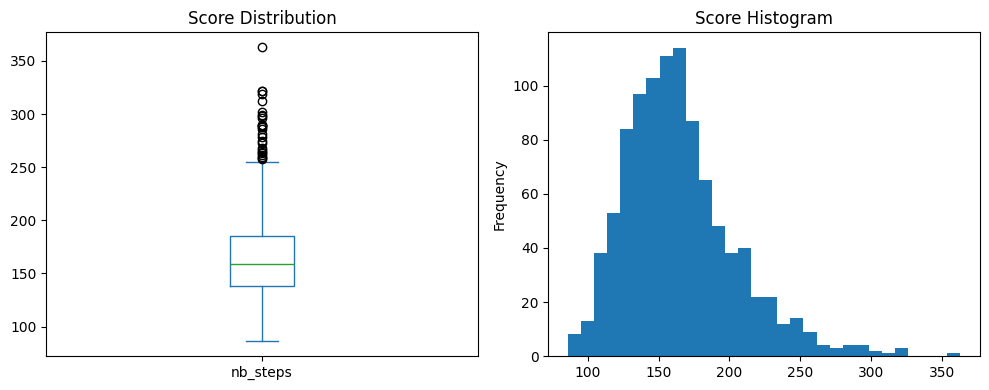


Model 3 — Comm 1 And Comm 2
---------------------------
Average Steps (terminated runs): 125.80
Max Steps: 270.00
Min Steps: 69.00
Termination Rate (%): 100.00
Avg comm_1 msgs: 133.53
Avg comm_2 msgs: 44.00


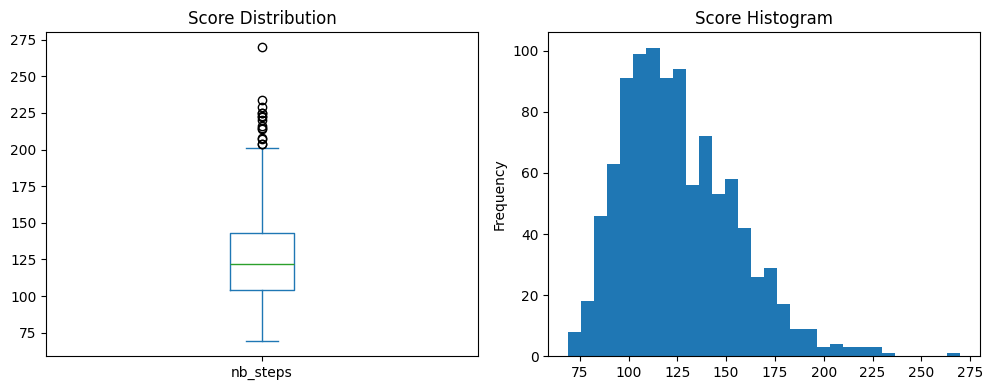

In [5]:
for model in model_order:
    print(f"Results for {model.replace('_',' ').title()} :")
    for scen in scenario_order:
        sub = all_df[(all_df['model']==model) & (all_df['scenario']==scen)]
        if not sub.empty:
            title = f"{model.replace('_',' ').title()} — {scen.replace('_',' ').title()}"
            show_results(sub, title=title)
    print("\n")

In [7]:
summary = all_df.groupby(['model','scenario']).agg(
    avg_steps=('steps_if_term','mean'),
    termination_rate=('terminated','mean'),
    avg_comm1=('nb_sent_msgs_comm_1','mean'),
    avg_comm2=('nb_sent_msgs_comm_2','mean')
).reset_index()

# Convert termination rate to percentage
summary['termination_rate'] *= 100

summary['model']    = pd.Categorical(summary['model'],    categories=model_order,    ordered=True)
summary['scenario'] = pd.Categorical(summary['scenario'], categories=scenario_order, ordered=True)
summary = summary.sort_values(['model','scenario']).reset_index(drop=True)

summary

C:\Users\moham\AppData\Local\Temp\ipykernel_21296\3074269026.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = all_df.groupby(['model','scenario']).agg(


,model,scenario,avg_steps,termination_rate,avg_comm1,avg_comm2
0,model_1,no_comm_no_drop,85.039216,61.2,0.000,0.0
1,model_1,no_comm_drop,115.259000,100.0,0.000,0.0
2,model_1,comm_1_only,67.158000,100.0,21.885,0.0
3,model_1,comm_1_and_comm_2,53.754000,100.0,21.387,12.0
4,model_2,no_comm_no_drop,101.371000,100.0,0.000,0.0
5,model_2,no_comm_drop,100.880000,100.0,0.000,0.0
6,model_2,comm_1_only,99.412000,100.0,0.000,0.0
7,model_2,comm_1_and_comm_2,69.895000,100.0,0.000,6.0
8,model_3,no_comm_no_drop,351.226994,16.3,0.000,0.0
9,model_3,no_comm_drop,499.934406,80.8,0.000,0.0


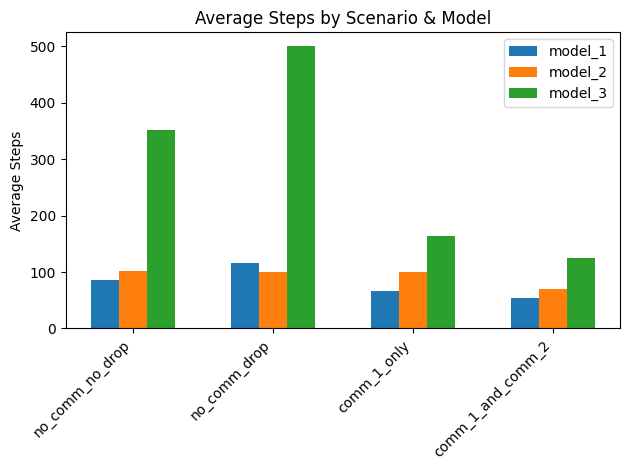

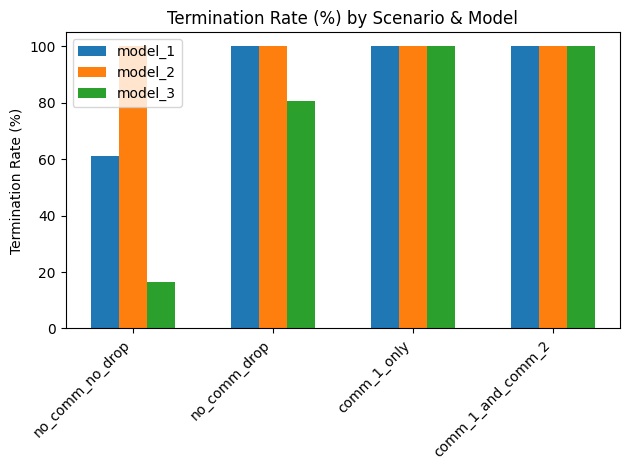

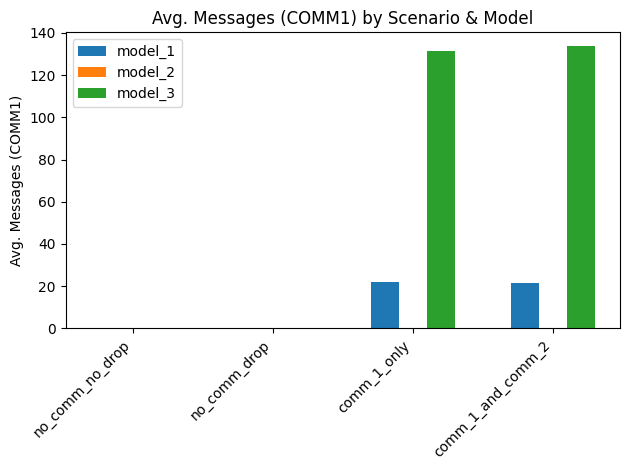

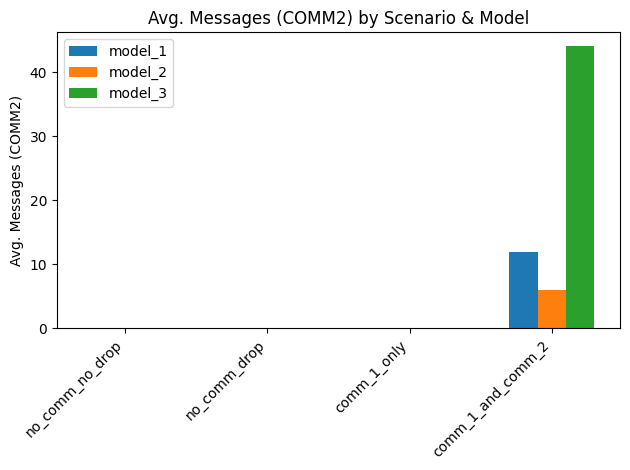

In [8]:
metrics = {
    'avg_steps': 'Average Steps',
    'termination_rate': 'Termination Rate (%)',
    'avg_comm1': 'Avg. Messages (COMM1)',
    'avg_comm2': 'Avg. Messages (COMM2)',
}

for metric, label in metrics.items():
    pivot = summary.pivot(index='scenario', columns='model', values=metric)
    x = range(len(pivot))
    width = 0.2

    fig, ax = plt.subplots()
    for i, model in enumerate(pivot.columns):
        ax.bar([pos + i*width for pos in x], pivot[model], width, label=model)

    ax.set_xticks([pos + width*(len(pivot.columns)-1)/2 for pos in x])
    ax.set_xticklabels(pivot.index, rotation=45, ha='right')
    ax.set_ylabel(label)
    ax.set_title(f"{label} by Scenario & Model")
    ax.legend()
    plt.tight_layout()
    plt.show()


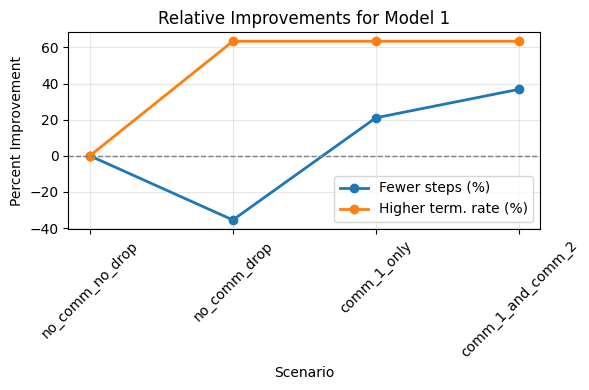

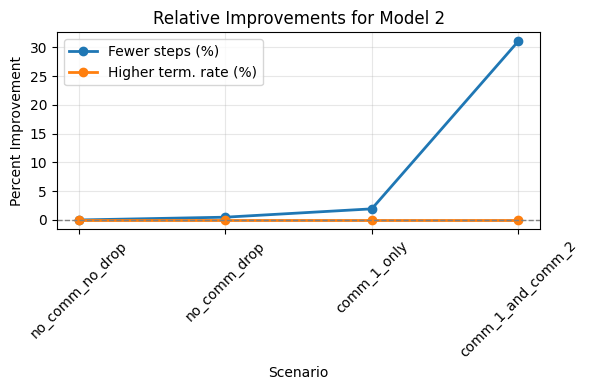

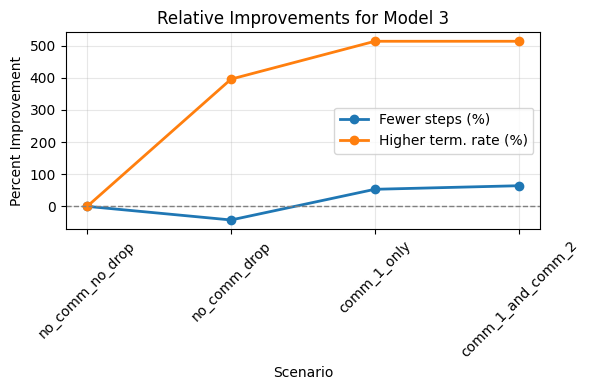

In [ ]:
for model in model_order:
    sub = (
        summary[summary.model == model]
        .set_index('scenario')
        .loc[scenario_order]
    )

    base_steps = sub.at['no_comm_no_drop', 'avg_steps']
    base_term  = sub.at['no_comm_no_drop', 'termination_rate']

    pct_steps = 100 * (base_steps - sub['avg_steps']) / base_steps
    pct_term  = 100 * (sub['termination_rate'] - base_term) / base_term

    improvements = pd.DataFrame({
        'Fewer steps (%)': pct_steps,
        'Higher term. rate (%)': pct_term
    }, index=sub.index)

    plt.figure(figsize=(6,4))
    for col in improvements.columns:
        plt.plot(
            improvements.index,
            improvements[col],
            marker='o',
            linewidth=2,
            label=col
        )

    plt.title(f"Relative Improvements for {model.replace('_',' ').title()}")
    plt.xlabel("Scenario")
    plt.ylabel("Percent Improvement")
    plt.xticks(rotation=45)
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.axhline(0, color='gray', linewidth=1, linestyle='--')  
    plt.tight_layout()
    plt.show()

In [ ]:
model_order    = ['model_1','model_2','model_3']
baseline       = 'no_comm_drop'
comm1_only     = 'comm_1_only'
comm1_and_comm2 = 'comm_1_and_comm_2'

rows = []
for model in model_order:
    sub = summary[summary.model == model].set_index('scenario')

    # margins
    Δ_steps_comm1 = sub.at[comm1_only,     'avg_steps'] - sub.at[baseline,    'avg_steps']
    Δ_msgs_comm1  = sub.at[comm1_only,     'avg_comm1'] - sub.at[baseline,     'avg_comm1']

    Δ_steps_comm2 = sub.at[comm1_and_comm2, 'avg_steps'] - sub.at[comm1_only, 'avg_steps']
    Δ_msgs_comm2_comm1 = sub.at[comm1_and_comm2, 'avg_comm1'] - sub.at[comm1_only, 'avg_comm1']
    Δ_msgs_comm2_comm2 = sub.at[comm1_and_comm2, 'avg_comm2'] 

    rows.append({
        'model': model,
        'step_savings_comm1': -Δ_steps_comm1,
        'msgs_added_comm1' :  Δ_msgs_comm1,
        'eff_comm1 (steps/msg)': -Δ_steps_comm1 / Δ_msgs_comm1,
        'step_savings_comm2': -Δ_steps_comm2,
        'msgs_added_comm2':  Δ_msgs_comm2_comm2,
        'eff_comm2 (steps/msg)': -Δ_steps_comm2 / Δ_msgs_comm2_comm2
    })

report = pd.DataFrame(rows)

report[['eff_comm1 (steps/msg)', 'eff_comm2 (steps/msg)']] = report[
    ['eff_comm1 (steps/msg)', 'eff_comm2 (steps/msg)']
].replace([np.inf, -np.inf], np.nan)

overall = report.mean(numeric_only=True).rename('overall')
overall_row = pd.DataFrame([ { **overall.to_dict(), 'model': 'overall' } ])

# concatenate
report = pd.concat([report, overall_row], ignore_index=True)

report

C:\Users\moham\AppData\Local\Temp\ipykernel_21296\1125654325.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  'eff_comm1 (steps/msg)': -Δ_steps_comm1 / Δ_msgs_comm1,


,model,step_savings_comm1,msgs_added_comm1,eff_comm1 (steps/msg),step_savings_comm2,msgs_added_comm2,eff_comm2 (steps/msg)
0,model_1,48.101000,21.885000,2.197898,13.404,12.000000,1.117000
1,model_2,1.468000,0.000000,NaN,29.517,6.000000,4.919500
2,model_3,335.234406,131.485000,2.549602,38.904,44.000000,0.884182
3,overall,128.267802,51.123333,2.373750,27.275,20.666667,2.306894


### Working on the results found when adding the battery

In [28]:
model_1_with_battery = pd.read_csv('benchmarks/with_battery/model_1_with_battery.csv')
model_2_with_battery = pd.read_csv('benchmarks/with_battery/model_2_with_battery.csv')
model_3_with_battery = pd.read_csv('benchmarks/with_battery/model_3_with_battery.csv')

models = [model_1_with_battery, model_2_with_battery, model_3_with_battery]



Model 1 with Battery
--------------------
Average Steps (terminated runs): 53.58
Max Steps: 93.00
Min Steps: 34.00
Termination Rate (%): 94.70
Avg comm_1 msgs: 21.38
Avg comm_2 msgs: 11.95


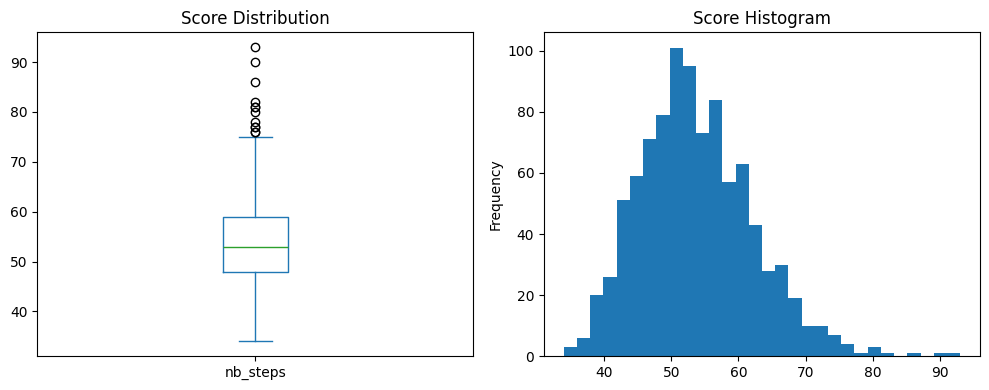


Model 2 with Battery
--------------------
Average Steps (terminated runs): 65.29
Max Steps: 96.00
Min Steps: 49.00
Termination Rate (%): 59.60
Avg comm_1 msgs: 0.00
Avg comm_2 msgs: 5.78


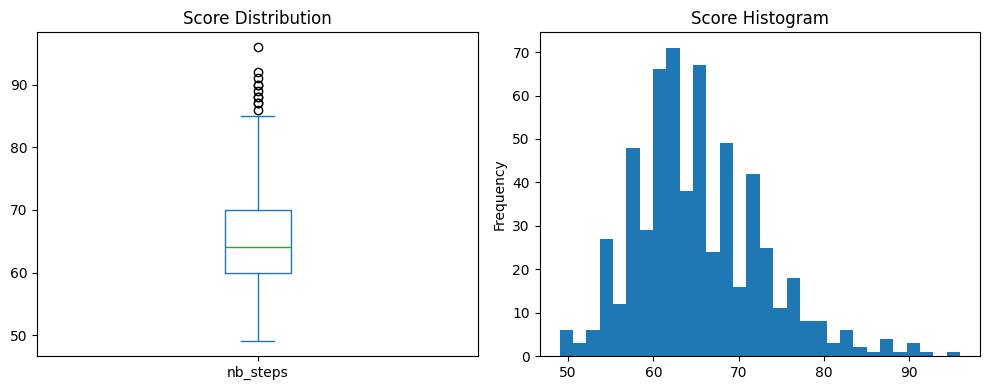


Model 3 with Battery
--------------------
Average Steps (terminated runs): 118.78
Max Steps: 201.00
Min Steps: 65.00
Termination Rate (%): 86.70
Avg comm_1 msgs: 132.81
Avg comm_2 msgs: 43.49


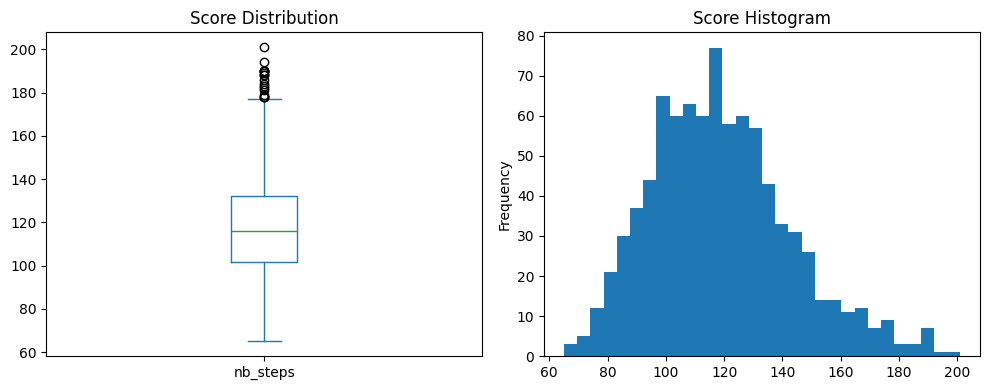

In [31]:
i=1
for model in models:
    model['steps_if_term'] = model['nb_steps'].where(model['terminated'], np.nan)
    model['steps_if_term'] = model['steps_if_term'].replace([np.inf, -np.inf], np.nan)
    model['terminated'] = model['terminated'].replace([np.inf, -np.inf], np.nan)

    show_results(model, title=f"Model {i} with Battery")
    i += 1

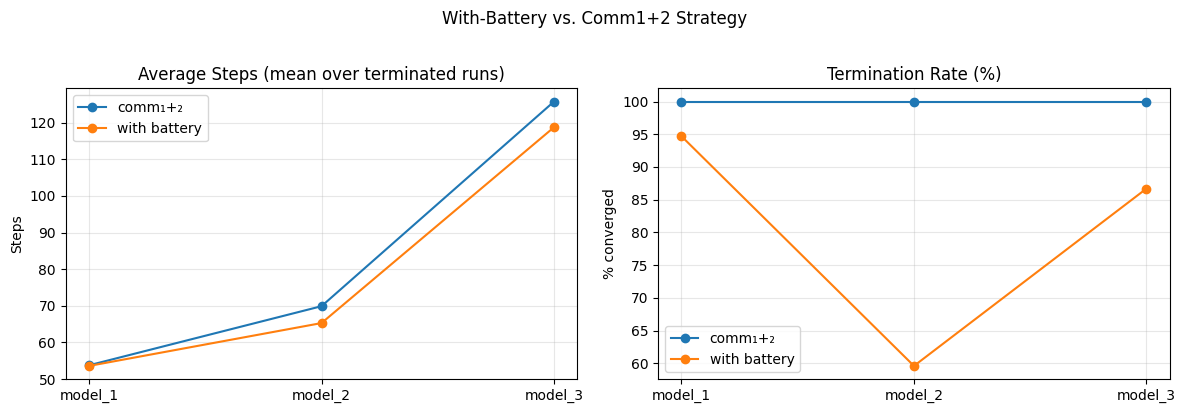

In [34]:
batt_dfs = []
for df, model in zip(models, ["model_1","model_2","model_3"]):
    d = df.copy()
    d["model"] = model
    d["steps_if_term"] = d["nb_steps"].where(d["terminated"], np.nan)
    batt_dfs.append(d)
df_batt = pd.concat(batt_dfs, ignore_index=True)

summary_batt = (
    df_batt
    .groupby("model")
    .agg(
        avg_steps_batt=("steps_if_term", "mean"),
        term_rate_batt = ("terminated",    "mean")
    )
    .reset_index()
)
summary_batt["term_rate_batt"] *= 100

summary_comm = (
    summary
    .query("scenario=='comm_1_and_comm_2'")
    .loc[:, ["model","avg_steps","termination_rate"]]
    .rename(columns={
        "avg_steps":"avg_steps_comm",
        "termination_rate":"term_rate_comm"
    })
)

cmp = pd.merge(summary_comm, summary_batt, on="model")


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4), sharex=True)

x = cmp["model"]

ax1.plot(x, cmp["avg_steps_comm"], marker="o", label="comm₁+₂")
ax1.plot(x, cmp["avg_steps_batt"], marker="o", label="with battery")
ax1.set_title("Average Steps (mean over terminated runs)")
ax1.set_ylabel("Steps")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(x, cmp["term_rate_comm"], marker="o", label="comm₁+₂")
ax2.plot(x, cmp["term_rate_batt"], marker="o", label="with battery")
ax2.set_title("Termination Rate (%)")
ax2.set_ylabel("% converged")
ax2.grid(alpha=0.3)
ax2.legend()

plt.suptitle("With‑Battery vs. Comm1+2 Strategy", y=1.02)
plt.tight_layout()
plt.show()
